<a href="https://colab.research.google.com/github/rmarharyta/machinelearning/blob/main/%D0%A0%D1%83%D0%B1%D0%BB%D0%B5%D0%BD%D0%BA%D0%BE_%D0%9B%D0%A03_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D1%88%D0%B0%D0%B1%D0%BB%D0%BE%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os





## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [26]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('house_price_regression_dataset.csv')

df



Saving house_price_regression_dataset.csv to house_price_regression_dataset (2).csv


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [25]:
import kagglehub

path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

df1 = pd.read_csv(os.path.join(path, "house_price_regression_dataset.csv"))
df1



Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [27]:
df.head(6)



,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
5,3944,5,3,1990,2.475930,2,8,8.797970e+05


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [29]:
print("Кількість дубльованих рядків:", df.duplicated().sum())


Кількість дубльованих рядків: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [30]:
print("Кількість пропущених значень в стовпчику Garage_Size: ",df.Garage_Size.isnull().sum())
print("Кількість пропущених значень в стовпчику House_Price: ", df.House_Price.isnull().sum())
print("Кількість пропущених значень в стовпчику Lot_Size: ", df.Lot_Size.isnull().sum())
print("Кількість пропущених значень в стовпчику Neighborhood_Quality: ", df.Neighborhood_Quality.isnull().sum())
print("Кількість пропущених значень в стовпчику Num_Bathrooms: ", df.Num_Bathrooms.isnull().sum())
print("Кількість пропущених значень в стовпчику Num_Bedrooms: ", df.Num_Bedrooms.isnull().sum())
print("Кількість пропущених значень в стовпчику Square_Footage: ", df.Square_Footage.isnull().sum())
print("Кількість пропущених значень в стовпчику Year_Built: ", df.Year_Built.isnull().sum())

Кількість пропущених значень в стовпчику Garage_Size:  0
Кількість пропущених значень в стовпчику House_Price:  0
Кількість пропущених значень в стовпчику Lot_Size:  0
Кількість пропущених значень в стовпчику Neighborhood_Quality:  0
Кількість пропущених значень в стовпчику Num_Bathrooms:  0
Кількість пропущених значень в стовпчику Num_Bedrooms:  0
Кількість пропущених значень в стовпчику Square_Footage:  0
Кількість пропущених значень в стовпчику Year_Built:  0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [32]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [34]:
df.Neighborhood_Quality.value_counts()




,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

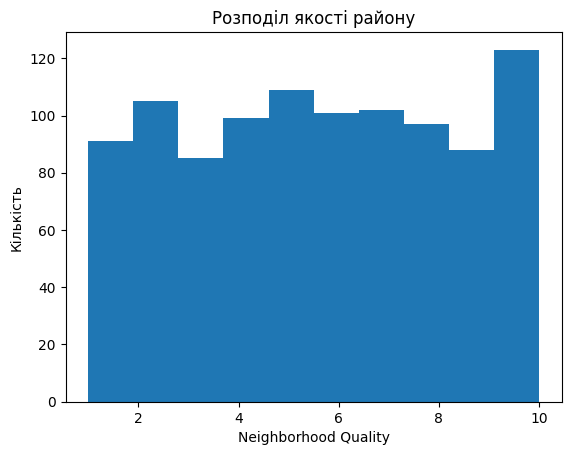

In [39]:
plt.hist(df['Neighborhood_Quality'], bins=10)
plt.xlabel('Neighborhood Quality')
plt.ylabel('Кількість')
plt.title('Розподіл якості району')
plt.show()


### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [36]:
df.Num_Bathrooms.value_counts()




,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

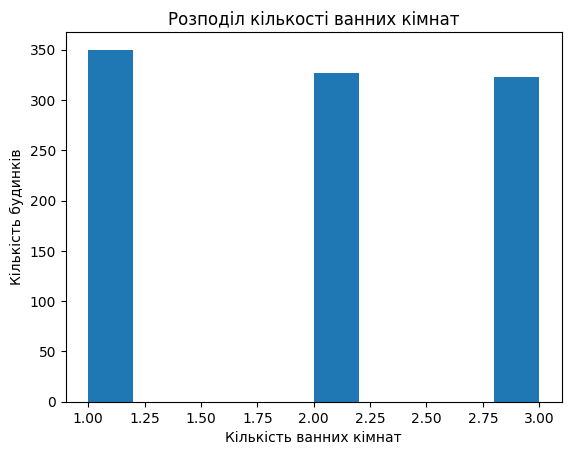

In [40]:
plt.hist(df['Num_Bathrooms'], bins=10)
plt.xlabel('Кількість ванних кімнат')
plt.ylabel('Кількість будинків')
plt.title('Розподіл кількості ванних кімнат')
plt.show()

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

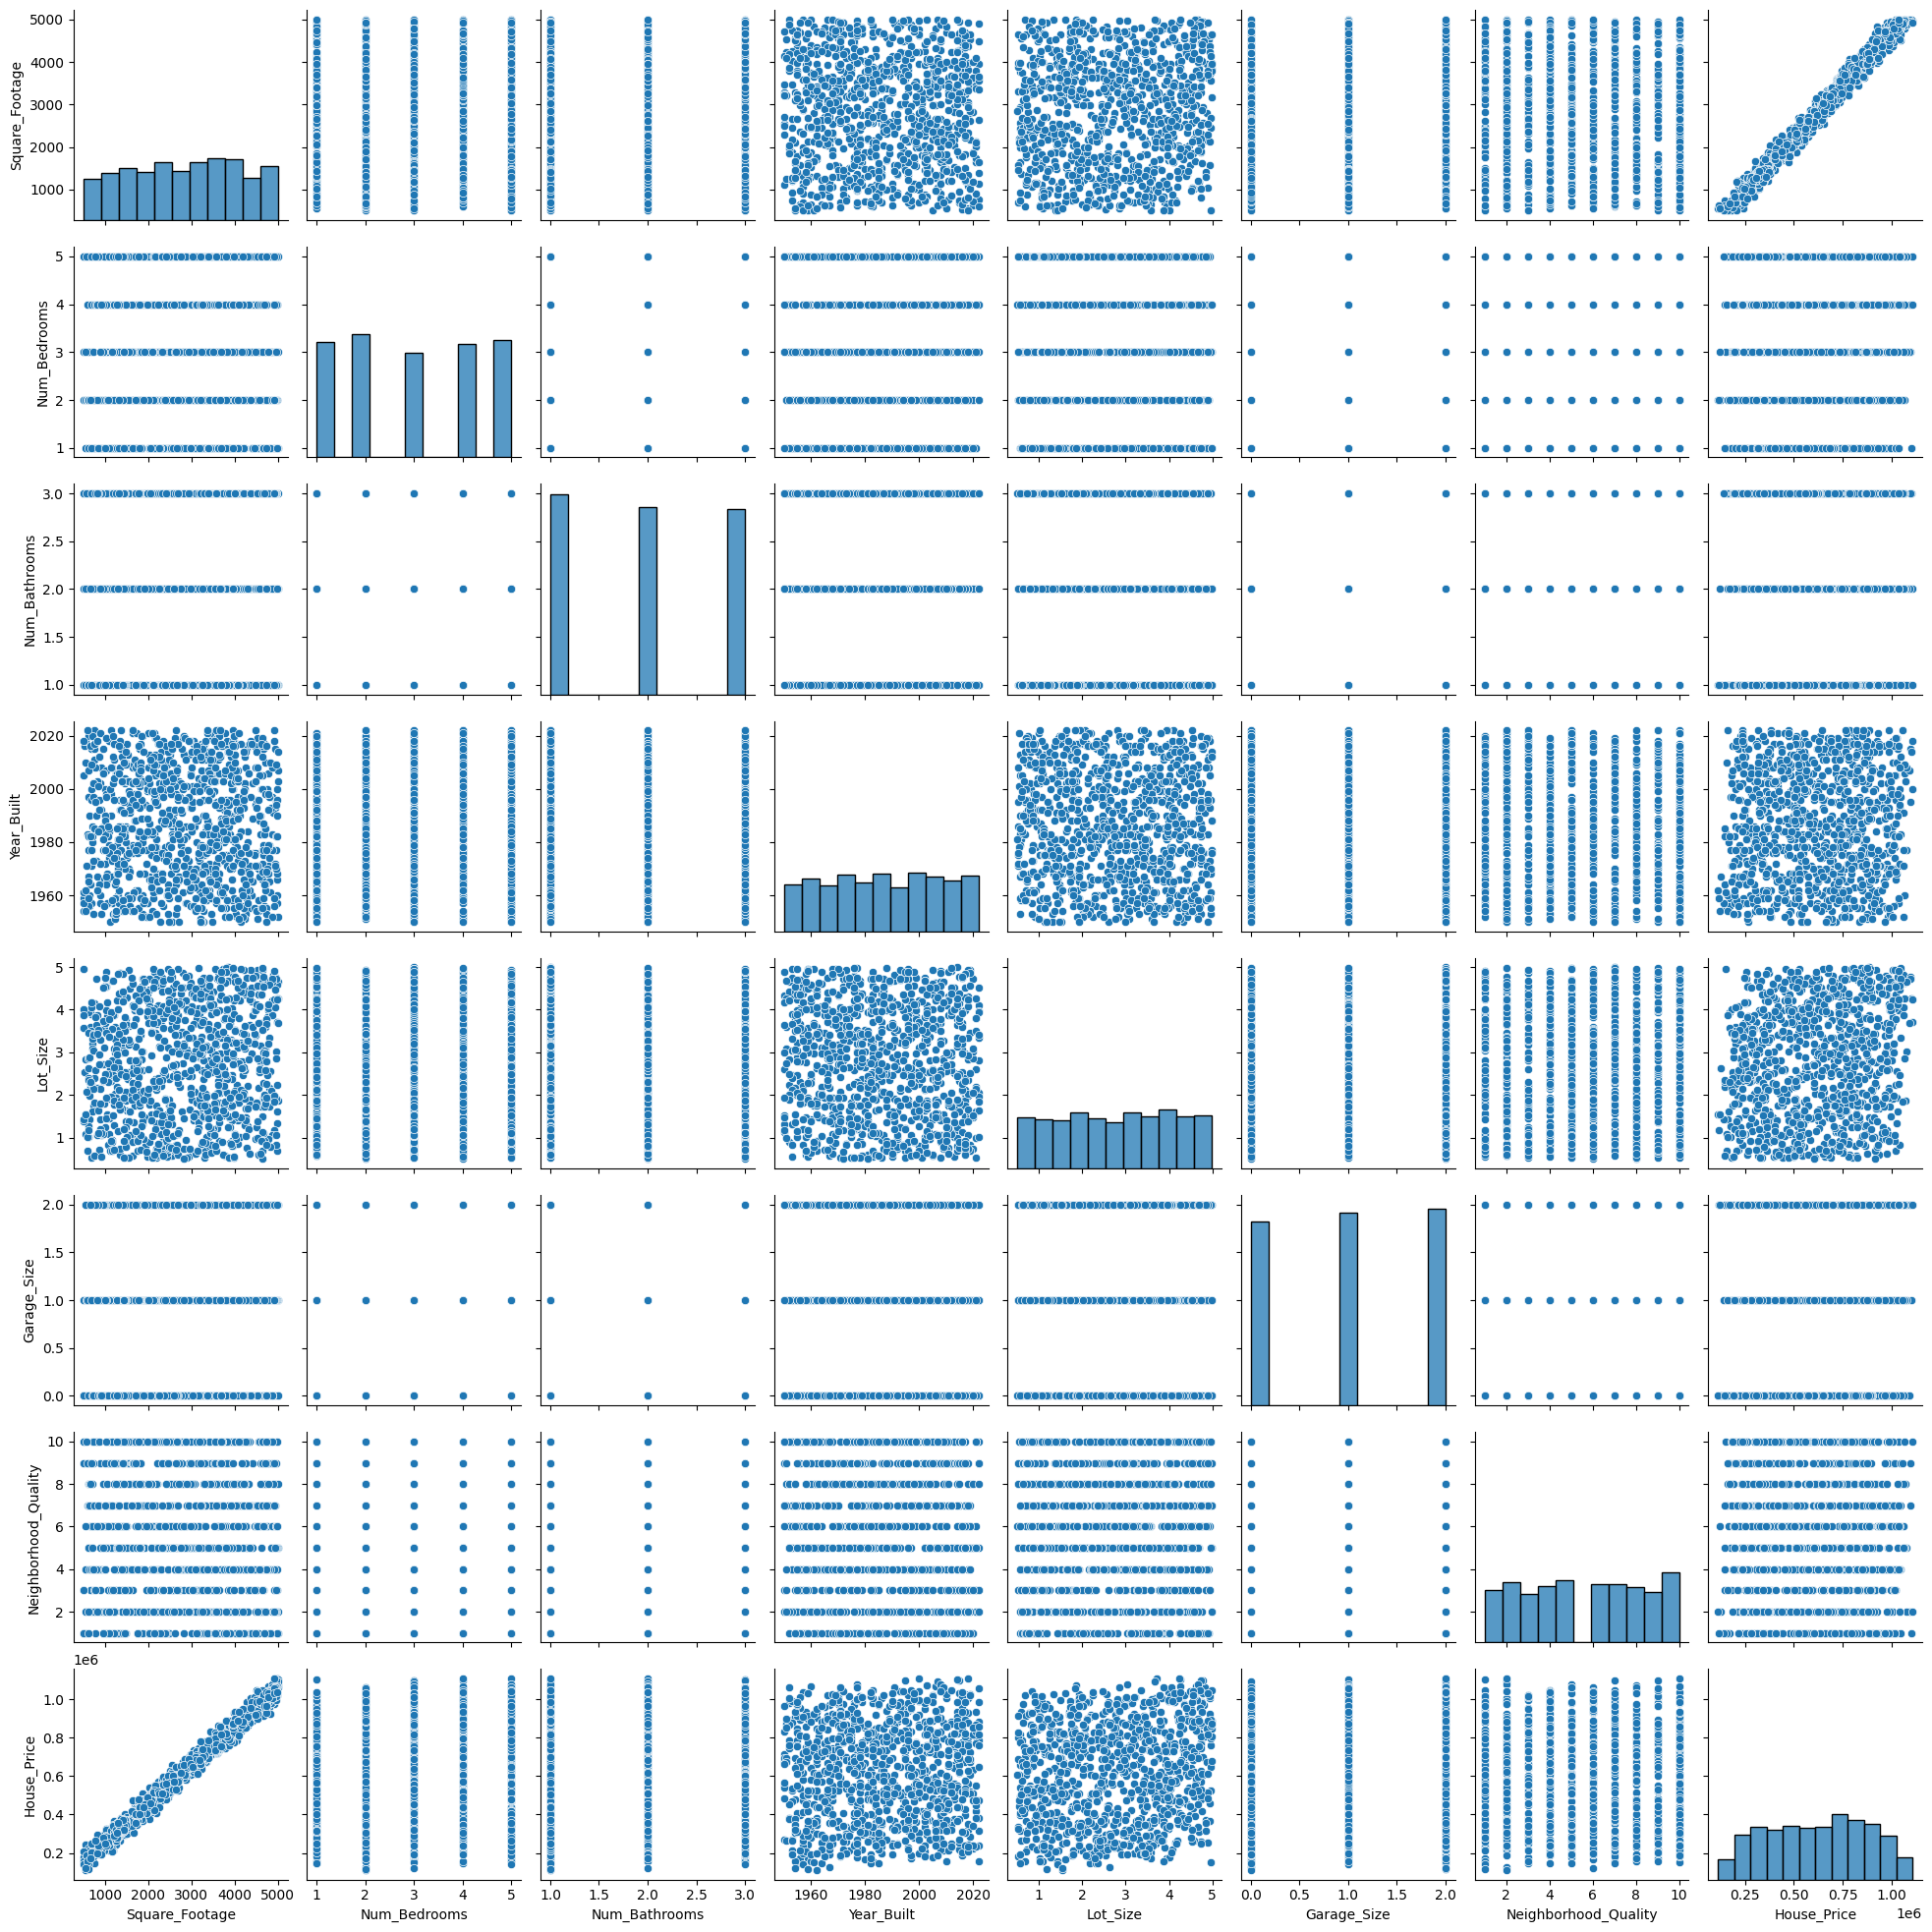

In [38]:
numeric_df = df.select_dtypes(include='number')

sns.pairplot(numeric_df)
plt.show()


Попарні графіки дають змогу оцінити залежності між числовими ознаками. За розташуванням точок можна визначити наявність позитивної або негативної кореляції, виявити можливі викиди та оцінити характер розподілу даних. Наприклад, якщо зі збільшенням площі будинку зростає його ціна, це свідчить про позитивну залежність між цими ознаками

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

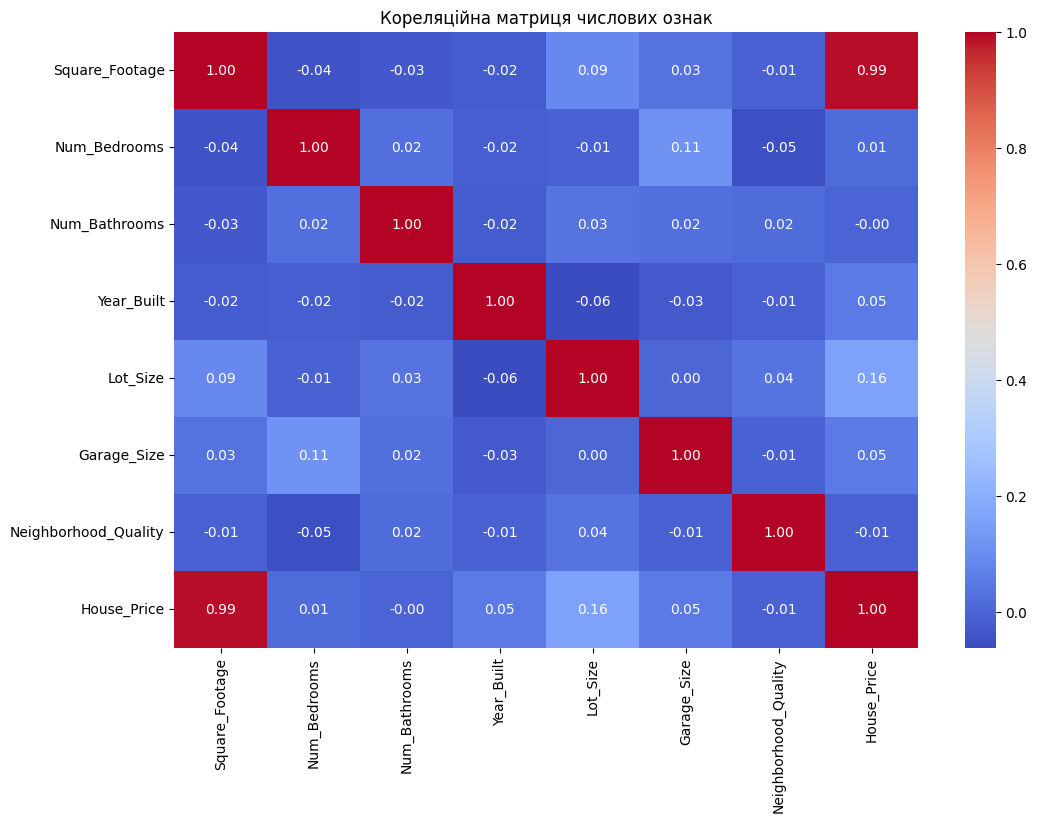

In [41]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Кореляційна матриця числових ознак')
plt.show()

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [42]:
correlation = df.select_dtypes(include='number').corr()['House_Price'].sort_values(ascending=False)

print(correlation)

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [45]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

print(X.head())
print(y.head())

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality  
0            0                     5  
1            1                     6  
2            0                     9  
3            1                     8  
4            0                     8  
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(800, 7)
(200, 7)
(800,)
(200,)


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [48]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

random_forest_model = RandomForestRegressor(
    random_state=42
)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

print("5 моделей створено.")


5 моделей створено.


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression': linear_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model,
    'Random Forest': random_forest_model,
    'Gradient Boosting': gradient_boosting_model
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R²': r2,
        'MAE': mae,
        'MSE': mse
    })

results_df = pd.DataFrame(results)

results_df



,Model,R²,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
3,Random Forest,0.993886,16114.289644,3.941317e+08
4,Gradient Boosting,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

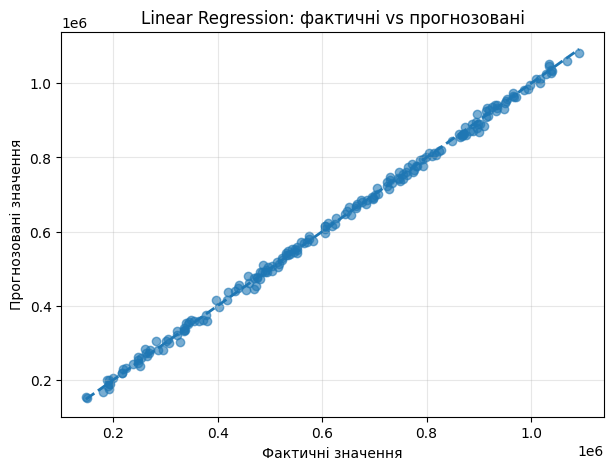

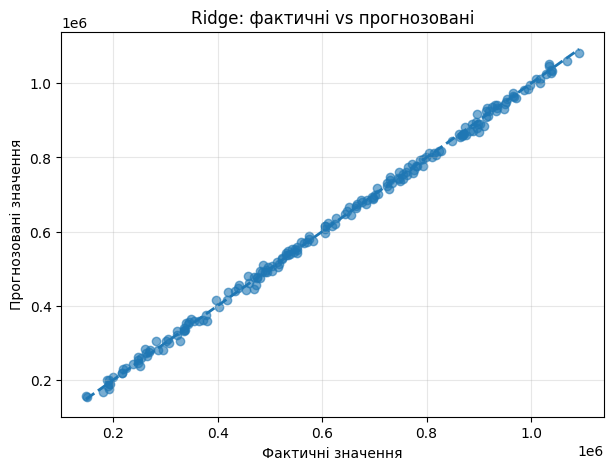

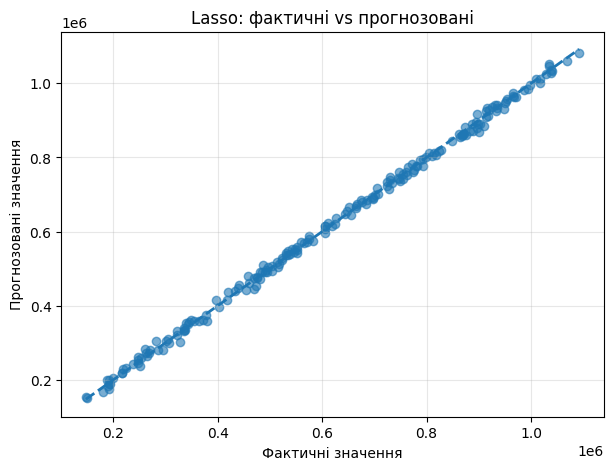

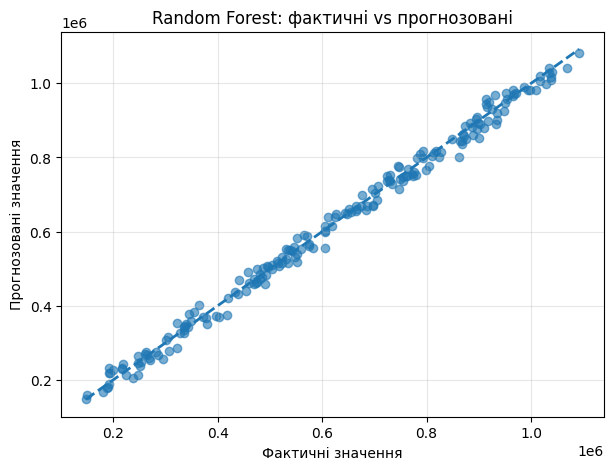

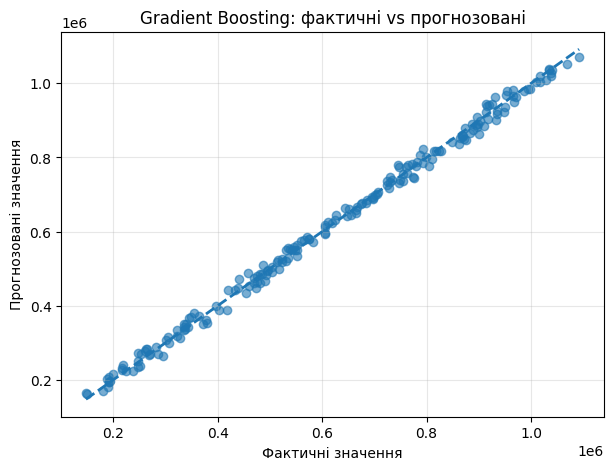

In [50]:
import matplotlib.pyplot as plt
import numpy as np

for name, model in models.items():

    y_pred = model.predict(X_test)


    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())


    plt.figure(figsize=(7, 5))

    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle='--',
        linewidth=2
    )

    plt.xlabel('Фактичні значення')
    plt.ylabel('Прогнозовані значення')
    plt.title(f'{name}: фактичні vs прогнозовані')
    plt.grid(True, alpha=0.3)

    plt.show()


## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    random_state=42
)


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Найкращі параметри:")
print(grid_search.best_params_)

print("\nНайкраще середнє R²:")
print(grid_search.best_score_)

Найкращі параметри:
{'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}

Найкраще середнє R²:
0.9919663079158397


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)

print("Результати найкращої моделі Random Forest:")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")




Результати найкращої моделі Random Forest:
R²: 0.9940
MAE: 16035.17
MSE: 387229091.92


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [53]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd


y_pred_base = random_forest_model.predict(X_test)


y_pred_optimized = best_rf.predict(X_test)


base_r2 = r2_score(y_test, y_pred_base)
base_mae = mean_absolute_error(y_test, y_pred_base)
base_mse = mean_squared_error(y_test, y_pred_base)


optimized_r2 = r2_score(y_test, y_pred_optimized)
optimized_mae = mean_absolute_error(y_test, y_pred_optimized)
optimized_mse = mean_squared_error(y_test, y_pred_optimized)


comparison_df = pd.DataFrame({
    'Модель': ['Random Forest (базова)', 'Random Forest (оптимізована)'],
    'R²': [base_r2, optimized_r2],
    'MAE': [base_mae, optimized_mae],
    'MSE': [base_mse, optimized_mse]
})

comparison_df



,Модель,R²,MAE,MSE
0,Random Forest (базова),0.993886,16114.289644,3.941317e+08
1,Random Forest (оптимізована),0.993993,16035.168080,3.872291e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**


Після підбору параметрів за допомогою `GridSearchCV` якість моделі **покращилася**, якщо порівняно з базовою моделлю значення `R²` зросло, а `MAE` та `MSE` зменшилися.

У результаті оптимізації змінилися всі три основні метрики: **R², MAE та MSE**. Оптимізована модель забезпечує точніші прогнози на тестовій вибірці, тому **її доцільно використовувати замість базової моделі**.


## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [54]:

y_pred_linear = linear_model.predict(X_test)


comparison_linear = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': y_pred_linear,
    'Похибка у %': np.abs((y_test.values - y_pred_linear) / y_test.values) * 100
})


comparison_linear.sample(10, random_state=42)


,Фактична ціна,Прогнозована ціна,Похибка у %
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

У ході лабораторної роботи було побудовано та досліджено п’ять моделей для прогнозування ціни нерухомості: **Linear Regression, Ridge, Lasso, Random Forest Regressor та Gradient Boosting Regressor**. Якість моделей оцінювалася за метриками **R², MAE та MSE**.

Найкращою виявилася модель, яка отримала **найвище значення R² та найнижчі значення MAE і MSE** на тестовій вибірці. Для `Random Forest` додатково було виконано підбір гіперпараметрів за допомогою `GridSearchCV`, що дозволило перевірити різні значення `n_estimators`, `max_features`, `max_depth` та `min_samples_split`. Після оптимізації якість моделі **покращилася**, що підтверджується змінами метрик.

Прогнози на тестовій вибірці є достатньо точними, а їх точність можна оцінити за значеннями `R²`, `MAE` та `MSE` і графіками фактичних та прогнозованих значень. На якість прогнозування ціни нерухомості можуть впливати **площа будинку, кількість спалень і ванних кімнат, якість району, розташування, характеристики будинку та інші фактори, представлені в датасеті**. Загалом проведене дослідження показало можливість використання алгоритмів машинного навчання для прогнозування вартості нерухомості.
